# EY Data Challenge: Predicting Urban Heat Islands

This is the submission for the EY 2025 Data Science Challenege where we attempted to assess the Urban Heat Island Effect in New York City. In this project, we placed 86th out of 2076 teams in the world with an accuracy of 0.9606 on the test data. In this notebook, you will see the entire data collection, EDA, feature engineering, and model development that achieved our final model score.

##### Packages

In [2]:
# Machine Learning
from sklearn.ensemble import RandomForestRegressor

# Feature Engineering
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Supress Warnings
import warnings
warnings.filterwarnings('ignore')

# Import Data Science Packages
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Import common GIS tools
import xarray as xr
import matplotlib.pyplot as plt
import rioxarray as rio
import rasterio
from matplotlib.cm import RdYlGn,jet,RdBu

# Geospatial raster data handling
import rioxarray as rxr

# Coordinate transformations
from pyproj import Proj, Transformer, CRS

# Others
import os
from tqdm import tqdm

# ckdTree for mapping 
from scipy.spatial import cKDTree

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score

# Import Planetary Computer tools
import stackstac
import pystac_client
import planetary_computer 
from odc.stac import stac_load


# set the number of columns we see
pd.set_option('display.max_columns',None)

# EY Data Set
EY was the creator of this data challenge, they provided contestants with 11229 training data points with 1040 test data points. The goal is to create a submission which has the highest correlation amongst the test data points they have kept and our predicted UHI values.

## Loading the EY Data

### UHI Training Data

In [3]:
uhi_train = pd.read_csv('/Users/ben_nicholson/Documents/vs_code/urban_heat_islands/ey_dataset/Training_data_uhi_index_2025-02-18.csv')
uhi_train.head()

,Longitude,Latitude,datetime,UHI Index
0,-73.909167,40.813107,24-07-2021 15:53,1.030289
1,-73.909187,40.813045,24-07-2021 15:53,1.030289
2,-73.909215,40.812978,24-07-2021 15:53,1.023798
3,-73.909242,40.812908,24-07-2021 15:53,1.023798
4,-73.909257,40.812845,24-07-2021 15:53,1.021634


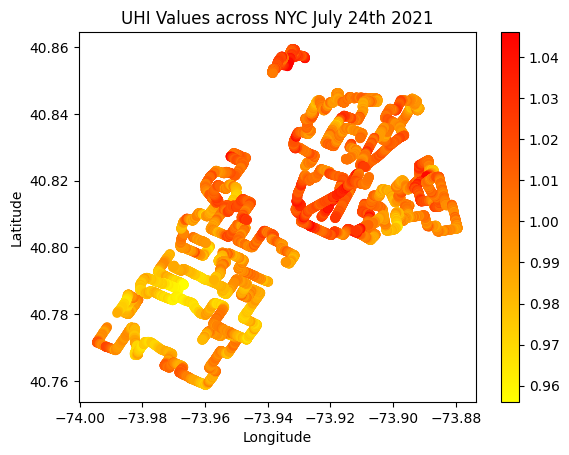

In [4]:
plt.scatter(uhi_train['Longitude'],uhi_train['Latitude'],c=uhi_train['UHI Index'],cmap='autumn_r')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('UHI Values across NYC July 24th 2021')
plt.colorbar()

We can see that UHI values range from 0.96 to 1.04. These values are calculated from looing at the specific temperature relative to the average of the city.

### UHI Testing Data

In [5]:
uhi_test = pd.read_csv('/Users/ben_nicholson/Documents/vs_code/urban_heat_islands/ey_dataset/Submission_template.csv')
uhi_test.head()

,Longitude,Latitude,UHI Index
0,-73.971665,40.788763,NaN
1,-73.971928,40.788875,NaN
2,-73.967080,40.789080,NaN
3,-73.972550,40.789082,NaN
4,-73.969697,40.787953,NaN


Text(0.5, 1.0, 'Test Data Locations')

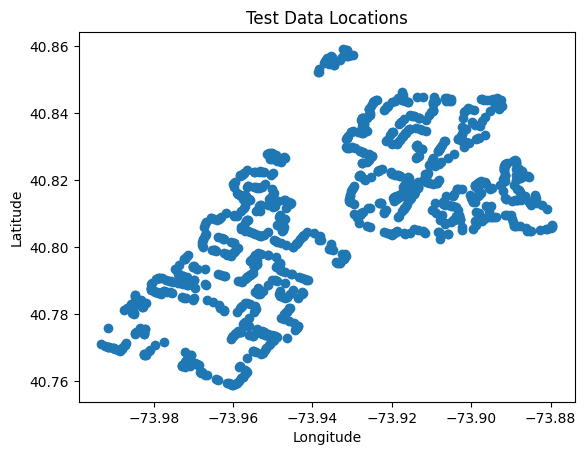

In [6]:
plt.scatter(uhi_test['Longitude'],uhi_test['Latitude'])
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Test Data Locations')

It is clear that the test data and the training data have relatively similar data points just with small differences in the long/lat points which surprisngly still show differences in temperatures.

# Satellite Imagery Creation

##### Functions

In [7]:
# create a function that can collect satellite data
def create_xarray_data(location, date_range, satellite, cloud_coverage, bands, resolution):
    """ 
    Fetch Sentinel-2 imagery as an xarray dataset.

    Parameters:
    - location: Tuple (min_lon, min_lat, max_lon, max_lat) defining the bounding box.
    - date_range: String in 'YYYY-MM-DD/YYYY-MM-DD' format defining the time window.
    - satellite: Name of the satellite collection (e.g., 'sentinel-2-l2a').
    - cloud_coverage: Max cloud cover percentage (integer, e.g., 30 for <30% clouds).
    - bands: List of band names (e.g., ['B02', 'B03', 'B04'] for RGB).
    - resolution: Desired spatial resolution in meters (e.g., 10m for Sentinel-2).

    Returns:
    - xarray.Dataset containing the requested satellite data.
    """

    # Define bounding box
    # Connect to Microsoft Planetary Computer STAC API
    stac = pystac_client.Client.open("https://planetarycomputer.microsoft.com/api/stac/v1")


    # Search for matching satellite imagery
    search = stac.search(
        bbox=location, 
        datetime=date_range,
        collections=[satellite],
        query={"eo:cloud_cover": {"lt": cloud_coverage}},
    )

    # Convert search results to a list
    items = list(search.get_items())
    print(f'Satellite Images Found: {len(items)}')

    if not items:
        raise ValueError("No STAC items found for the given parameters.")

    # Sign the items for access
    signed_items = [planetary_computer.sign(item) for item in items]

    # Load data using stackstac
    data = stac_load(
        signed_items,
        bands=bands,
        crs="EPSG:4326",  # Latitude-Longitude
        resolution=resolution / 111320.0,  # Ensure resolution is in meters
        chunks={"x": 2048, "y": 2048},  # Optimize chunking
        dtype="uint16",
        patch_url=planetary_computer.sign,
        bbox=location
    )

    return data


In [8]:
def sentinel_1_xarray(location,date_range,satellite,bands):
    # Step 1: Connect to the Planetary Computer STAC API
    catalog_url = "https://planetarycomputer.microsoft.com/api/stac/v1"
    catalog = pystac_client.Client.open(catalog_url)

    # Step 2: Define your search parameters
    time_range = "2021-07-26/2021-07-26"  # Up to current date, July 26th 2021

    search = catalog.search(
        collections=[satellite],  # Sentinel-1 GRD product
        bbox=location,
        datetime=date_range,
        limit=10
    )

    # Step 3: Retrieve the items
    items = list(search.items())
    print(f"Found {len(items)} Sentinel-1 scenes.")

    signed_items = [planetary_computer.sign(item).to_dict() for item in items]

        # Define the pixel resolution for the final product
    # Define the scale according to our selected crs, so we will use degrees
    resolution = 10  # meters per pixel 
    scale = resolution / 111320.0 # degrees per pixel for crs=4326 

    # 'items' is a list of STAC Items from a prior search (e.g., via pystac_client)
    sentinel_1_july_26th = stac_load(
        items,                           # STAC Items from Sentinel-1 GRD search
        bands=bands,             # Sentinel-1 polarization bands
        crs="EPSG:4326",                # Latitude-Longitude coordinate system
        resolution=scale,               # Degrees (set 'scale' to desired resolution, e.g., 0.0001 for ~10 m)
        chunks={"x": 2048, "y": 2048},  # Dask chunks for lazy loading
        dtype="uint16",                 # GRD data typically uint16 (check metadata if float32 needed)
        patch_url=planetary_computer.sign,  # Sign URLs for Planetary Computer access
        bbox=location                     # Bounding box in EPSG:4326 [min_lon, min_lat, max_lon, max_lat]
    )

    return sentinel_1_july_26th

In [9]:
import os

def output_file(filename, image_data, bounds, bands, location):
    """
    Saves a multi-band raster (GeoTIFF) from an xarray dataset.

    Parameters:
    - filename (str): Name of the output file (e.g., "output.tif").
    - image_data (xarray.DataArray or xarray.Dataset): The dataset containing band data.
    - bounds (tuple): Bounding box (min_lon, min_lat, max_lon, max_lat).
    - bands (list): List of band names to include in the output file.

    Returns:
    - None (Saves the GeoTIFF file)
    """

    filename = os.path.join(location, filename)
    
    # Extract width and height from dataset dimensions
    height = image_data.dims["latitude"]
    width = image_data.dims["longitude"]
    
    # Create raster transform using bounding box
    gt = rasterio.transform.from_bounds(bounds[0], bounds[1], bounds[2], bounds[3], width, height)

    # Assign CRS and transform to the dataset
    image_data.rio.write_crs("epsg:4326", inplace=True)
    image_data.rio.write_transform(transform=gt, inplace=True)

    # Create GeoTIFF output file
    with rasterio.open(filename, 'w', driver='GTiff', width=width, height=height,
                       crs='epsg:4326', transform=gt, count=len(bands),
                       compress='lzw', dtype='float64') as dst:
        for i, band in enumerate(bands):
            dst.write(image_data[band].values, i + 1)  # Ensure NumPy array format

    print(f"GeoTIFF saved: {filename}")

In [10]:
# function to create a median mosaic
def median_mosaic(data):
    median = data.median(dim='time').compute()
    return median

## Sentinel 2 Data
- Location - NYC
- Time Window - Summer 2021
- Satellite - Sentinel 2
- Cloud Coverage - <30%
- Bands - ("B01", "B02", "B03", "B04", "B05", "B06", "B07", "B08", "B8A", "B11", "B12")

In [11]:
nyc_location = (-74.00, 40.75, -73.87, 40.86) # Bounding box for NYC
summer_2021 = "2021-06-01/2021-09-01"         # Summer 2021
satellite = "sentinel-2-l2a"                  # Sentinel-2 Level 2A
cloud_coverage = 30                           # Max 30% cloud cover
sentinel_2_bands = ["B01", "B02", "B03", "B04", "B05", "B06", "B07", "B08", "B8A", "B11", "B12"] # Sentinel 2 Bands
resolution = 10 # Resolution of 10m      

summer_sentinel_2_xarray = create_xarray_data(nyc_location,summer_2021,satellite,cloud_coverage,sentinel_2_bands,resolution)

Satellite Images Found: 10


In [12]:
# now lets created a median mosaic
# a median mosaic is taking the middle value when the x array data is sorted
# this is done to remove clouds which may impact the sentinel 2 values
# known as statistically removing clouds
summer_sentinel_2 = median_mosaic(summer_sentinel_2_xarray)

In [ ]:
output_file('sentinel_2_summer.tiff',summer_sentinel_2,nyc_location,summer_sentinel_2,'/Users/ben_nicholson/Documents/vs_code/urban_heat_islands/satellite_images')

GeoTIFF saved: /Users/ben_nicholson/Documents/vs_code/urban_heat_islands/satellite_images/sentinel_2_summer.tiff


### Sentinel 1 Data
- Location - NYC
- Time Window - July 26th 2021
- Satellite - Sentinel 1
- Cloud Coverage - 10
- Sentinel 1 - (vv,vh)
- Resolution - 30

In [ ]:
nyc_location = (-74.00, 40.75, -73.87, 40.86) # Bounding box for NYC
sentinel_1_date = '2021-07-26/2021-07-26'     # Sentinel 1 date
sentinel_1 = "sentinel-1-grd"                 # Sentinel-1 GRD
low_cloud_coverage = 0                        # Max 10% cloud cover
sentinel_1_all_bands = ['vv','vh']            # Sentinel 1 bands
resolution = 10                               # 10m resolution

sentinel_1_july_26_xarray = sentinel_1_xarray(nyc_location,sentinel_1_date,sentinel_1,sentinel_1_all_bands)

Found 1 Sentinel-1 scenes.


In [ ]:
sentinel_1_july_26 = median_mosaic(sentinel_1_july_26_xarray)

In [ ]:
output_file('sentinel_1_07_26.tiff',sentinel_1_july_26,nyc_location,sentinel_1_all_bands,'/Users/ben_nicholson/Documents/vs_code/urban_heat_islands/satellite_images')

GeoTIFF saved: /Users/ben_nicholson/Documents/vs_code/urban_heat_islands/satellite_images/sentinel_1_07_26.tiff


### Landsat Data
- Location - NYC
- Time Window - Summer 2021
- Satellite - Landsat 8
- Cloud Coverage - 30
- Bands - (lwir11,red,green,blue,nir08)
- Resolution - 30

#### Thermal

In [ ]:
nyc_location = (-74.00, 40.75, -73.87, 40.86)  # Bounding box for NYC
landsat_date = "2021-05-15/2021-05-15"         # Landsat date - closest temperature to test data
landsat = "landsat-c2-l2"                      # Landsat 8 Satellite
cloud_coverage = 30                            # Max 30% cloud cover
thermal_bands = ["lwir11"]                     # landsat bands
resolution = 10                                # 10m resolution

landsat_thermal_05_may_xarray = create_xarray_data(nyc_location,landsat_date,landsat,cloud_coverage,thermal_bands,resolution)

Satellite Images Found: 1


In [ ]:
landsat_thermal_05_may = median_mosaic(landsat_thermal_05_may_xarray)

In [ ]:
# Scale Factors for the Surface Temperature band
scale2 = 0.00341802
offset2 = 149.0
kelvin_celsius = 273.15 # convert from Kelvin to Celsius
landsat_thermal_05_may = landsat_thermal_05_may.astype(float) * scale2 + offset2 - kelvin_celsius

In [ ]:
output_file('landsat_thermal_05_may.tiff',landsat_thermal_05_may,nyc_location,thermal_bands,'/Users/ben_nicholson/Documents/vs_code/urban_heat_islands/satellite_images')

GeoTIFF saved: /Users/ben_nicholson/Documents/vs_code/urban_heat_islands/satellite_images/landsat_thermal_05_may.tiff


#### Non Thermal Bands

In [ ]:
nyc_location = (-74.00, 40.75, -73.87, 40.86)  # Bounding box for NYC
landsat_summer_date = "2021-06-01/2021-09-01"  # Landsat Summer Date
landsat = "landsat-c2-l2"                      # Landsat 8 Satellite
cloud_coverage = 30                            # Max 30% cloud cover
non_thermal_bands = ['red','blue','green','nir08'] # landsat bands
resolution = 10    

landsat_non_thermal_05_may_xarray = create_xarray_data(nyc_location,landsat_summer_date,landsat,cloud_coverage,non_thermal_bands,resolution)

Satellite Images Found: 13


In [ ]:
landsat_non_thermal_05_may = median_mosaic(landsat_non_thermal_05_may_xarray)

In [ ]:
# Scale Factors for the RGB and NIR bands
scale1 = 0.0000275
offset1 = -0.2
landsat_thermal_05_may_xarray[['red','blue','green','nir08']] = landsat_non_thermal_05_may[['red','blue','green','nir08']].astype(float) * scale1 + offset1

In [ ]:
output_file('landsat_non_thermal_05_may.tiff', landsat_non_thermal_05_may, nyc_location, non_thermal_bands,'/Users/ben_nicholson/Documents/vs_code/urban_heat_islands/satellite_images')

GeoTIFF saved: /Users/ben_nicholson/Documents/vs_code/urban_heat_islands/satellite_images/landsat_non_thermal_05_may.tiff


# NYC Data
NYC Open Data is an open source collection of data that can be used for public use.

We will be looking at natural elevation apart of the planmetric tracking of data as well as building elevation.

##### Functions

In [ ]:
def add_nearest_data(uhi_data: pd.DataFrame, data_to_map: pd.DataFrame) -> pd.DataFrame:
    """
    Adds the nearest elevation value to the UHI dataset using a KDTree for fast nearest-neighbor search.
    
    Parameters:
        uhi_data (pd.DataFrame): DataFrame containing UHI data with 'Latitude' and 'Longitude' columns.
        elevation_data (pd.DataFrame): DataFrame containing elevation data with 'Latitude', 'Longitude', and 'z_grade' columns.

    Returns:
        pd.DataFrame: UHI dataset with an added 'Elevation' column.
    """
    # Extract coordinates from both datasets
    elevation_coords = np.array(list(zip(data_to_map["Latitude"], data_to_map["Longitude"])))
    uhi_coords = np.array(list(zip(uhi_data["Latitude"], uhi_data["Longitude"])))
    
    # Build KDTree for fast nearest-neighbor search
    tree = cKDTree(elevation_coords)
    
    # Find the nearest elevation point for each UHI point
    distances, indices = tree.query(uhi_coords)
    
    # Add the matched elevation values to the UHI dataset
    uhi_data = uhi_data.copy()

    for col in data_to_map.drop(columns=['Longitude','Latitude']):
        uhi_data[col] = data_to_map.iloc[indices][col].values
    
    return uhi_data

## Building Elevation Data


### Granular Elevation Data
Throughout this project we are going to compare granular and proximity data this is an extremely successful effort in generalizing the model to be applicable to data points not seen before.

In [ ]:
# load the data
building_elevation_original = pd.read_csv('/Users/ben_nicholson/Documents/vs_code/urban_heat_islands/original_data/planimetric_building_elevation.csv')

# create a dataframe
building_elevation = pd.DataFrame()

# get the longitude and latitude using string detection
building_elevation[['Longitude','Latitude']] = building_elevation_original['the_geom'].str.extract(r'POINT \((-?\d+\.\d+) (-?\d+\.\d+)\)')

# add relevant columns
building_elevation[['Feature Code','Building Elevation']] = building_elevation_original[['FEAT_CODE','ELEVATION']]

# save building elevation as an integer value
building_elevation = building_elevation.astype(float)

building_elevation.head()

,Longitude,Latitude,Feature Code,Building Elevation
0,-73.910978,40.619529,3000.0,8.916312
1,-73.899553,40.619519,3000.0,7.617787
2,-73.853139,40.653806,3000.0,8.680600
3,-73.853136,40.655165,3000.0,8.831100
4,-73.853131,40.657272,3000.0,8.672700


In [ ]:
# 3020 is the code used for building elevation
building_elevation = building_elevation[building_elevation['Feature Code'] == 3020]
building_elevation = building_elevation.drop(columns='Feature Code')

In [ ]:
# get the specific data used from the training data
long_min,long_max,lat_min,lat_max = nyc_location

manhattan_bronx_area = (
    building_elevation['Longitude'].between(long_min,long_max) &
    building_elevation['Latitude'].between(lat_min,lat_max)
)

# use the boolean mask to update building elevation
building_elevation = building_elevation[manhattan_bronx_area]

building_elevation.head()

,Longitude,Latitude,Building Elevation
84,-73.943214,40.652620,60.09
97,-73.925203,40.619571,43.04
98,-73.932564,40.619576,40.60
102,-73.930605,40.619578,46.61
103,-73.932095,40.619580,27.88


Text(0, 0.5, 'Latitude')

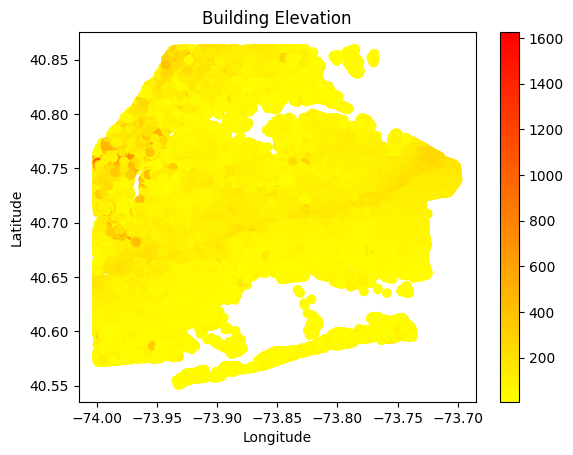

In [ ]:
plt.scatter(building_elevation['Longitude'],building_elevation['Latitude'],c=building_elevation['Building Elevation'],cmap='autumn_r')
plt.title('Building Elevation')
plt.colorbar()
plt.xlabel('Longitude')
plt.ylabel('Latitude')

### Proximity Elevation Data
Using proximity elevation is going to be done using a grid.

In [ ]:
building_elevation_proximity = building_elevation.copy()

building_elevation_proximity[['Longitude','Latitude']] = building_elevation[['Longitude','Latitude']].round(3)

In [ ]:
# group by the long and lat data points to have multiple values per location 
# use the median to find the values
building_elevation_proximity.groupby(['Longitude','Latitude']).median().reset_index()

,Longitude,Latitude,Building Elevation
0,-74.000,40.573,158.450000
1,-74.000,40.574,103.059983
2,-74.000,40.575,40.910000
3,-74.000,40.578,70.720000
4,-74.000,40.580,70.050253
...,...,...,...
45647,-73.701,40.751,140.548892
45648,-73.701,40.752,150.982696
45649,-73.700,40.739,129.159722
45650,-73.700,40.740,134.416394


Text(0, 0.5, 'Latitude')

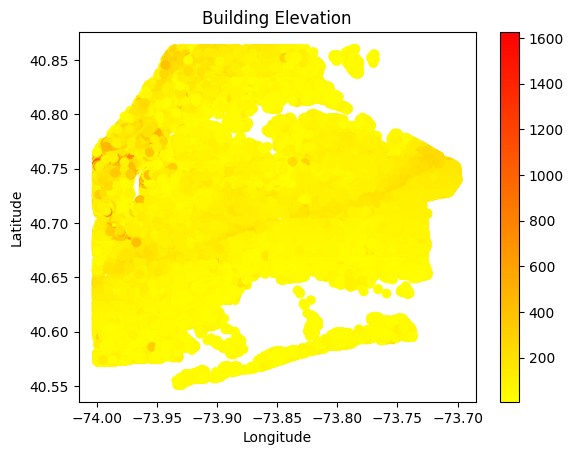

In [ ]:
plt.scatter(building_elevation_proximity['Longitude'],building_elevation_proximity['Latitude'],c=building_elevation['Building Elevation'],cmap='autumn_r')
plt.title('Building Elevation')
plt.colorbar()
plt.xlabel('Longitude')
plt.ylabel('Latitude')

In [ ]:
# save the building elevation proximity to be used in training process
building_elevation_proximity.to_csv('/Users/ben_nicholson/Documents/vs_code/urban_heat_islands/created_data/nyc_data/building_elevation_proximity.csv')

In [ ]:
building_elevation_proximity_data = add_nearest_data(uhi_train,building_elevation_proximity)

building_elevation_proximity_data.head()

,Longitude,Latitude,datetime,UHI Index,Building Elevation
0,-73.909167,40.813107,24-07-2021 15:53,1.030289,69.58
1,-73.909187,40.813045,24-07-2021 15:53,1.030289,69.58
2,-73.909215,40.812978,24-07-2021 15:53,1.023798,69.58
3,-73.909242,40.812908,24-07-2021 15:53,1.023798,69.58
4,-73.909257,40.812845,24-07-2021 15:53,1.021634,69.58


## Natural Elevation

### Granular Natural Elevation

In [ ]:
# load in natural elevation
natural_elevation = pd.read_csv('/Users/ben_nicholson/Documents/vs_code/urban_heat_islands/original_data/natural_elevation.csv')

# get the relevant columns
natural_elevation[['Longitude','Latitude','Natural Elevation']] = natural_elevation[['longitude','latitude','z_grade']]

natural_elevation = natural_elevation[['Longitude','Latitude','Natural Elevation']]

# output the natural elevation
natural_elevation.head()

,Longitude,Latitude,Natural Elevation
0,-74.215896,40.549105,65.472
1,-74.149890,40.630853,29.370
2,-74.037379,40.631601,28.861
3,-74.010281,40.606650,22.192
4,-74.000341,40.611148,33.157


### Proximity Natural Elevation

In [ ]:
natural_elevation[['Longitude','Latitude']] = natural_elevation[['Longitude','Latitude']].round(3)

natural_elevation_proximity = natural_elevation.groupby(['Longitude','Latitude']).median().reset_index()

Text(0, 0.5, 'Latitude')

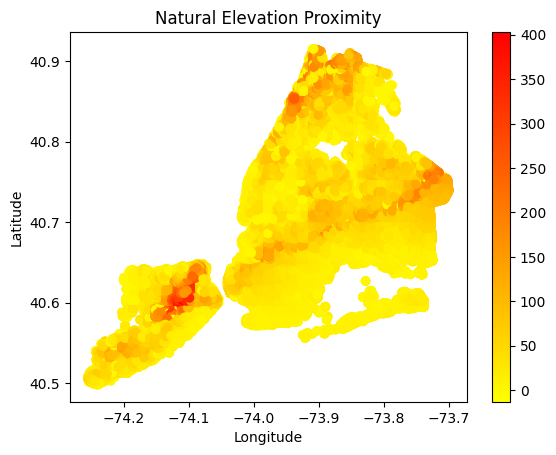

In [ ]:
plt.scatter(natural_elevation['Longitude'],natural_elevation['Latitude'],c=natural_elevation['Natural Elevation'],cmap='autumn_r')
plt.title('Natural Elevation Proximity')
plt.colorbar()
plt.xlabel('Longitude')
plt.ylabel('Latitude')

In [ ]:
natural_elevation_proximity.to_csv('/Users/ben_nicholson/Documents/vs_code/urban_heat_islands/created_data/nyc_data/natural_elevation_proximity.csv')

In [ ]:
natural_elevation_proximity_data = add_nearest_data(uhi_train,natural_elevation_proximity) 

natural_elevation_proximity_data.head()

,Longitude,Latitude,datetime,UHI Index,Natural Elevation
0,-73.909167,40.813107,24-07-2021 15:53,1.030289,34.726
1,-73.909187,40.813045,24-07-2021 15:53,1.030289,34.726
2,-73.909215,40.812978,24-07-2021 15:53,1.023798,34.726
3,-73.909242,40.812908,24-07-2021 15:53,1.023798,34.726
4,-73.909257,40.812845,24-07-2021 15:53,1.021634,34.726


# Loading Satellite Data
As we load in satellite data, we want to perform a similar activity as elevation data where we use a proximity to get values of data to use. However, when we are working with 11229 training data points, it is not enough to create proximity data which is accurate so we are going to artifically create noise in the creation of satellite data.

1. Add n random noise of data around a point
2. Map satellite data to all points
3. Create grid like structure using long/lat rounding
4. Collect similar long/lat points
5. Get the median value

When we have this data we can map whatever training data we have to the nearest proximity data point to get the most generalized version of a data point.

##### Functions

In [ ]:
def map_satellite_data(tiff_path,training_data, band_names):
    # Load the GeoTIFF data
    data = rxr.open_rasterio(tiff_path)
    tiff_crs = data.rio.crs

    # Read the CSV file
    latitudes = training_data['Latitude'].values
    longitudes = training_data['Longitude'].values

    # Convert lat/long to the GeoTIFF's CRS
    proj_wgs84 = Proj(init='epsg:4326')  
    proj_tiff = Proj(tiff_crs)
    transformer = Transformer.from_proj(proj_wgs84, proj_tiff)

    # Reproject coordinates
    transformed_coords = [transformer.transform(lat, lon) for lat, lon in zip(latitudes, longitudes)]
    xs, ys = zip(*transformed_coords)

    # Get available band numbers
    band_numbers = data.coords["band"].values
    
    # Validate that the user provided the correct number of band names
    if len(band_names) != len(band_numbers):
        raise ValueError(f"Expected {len(band_numbers)} band names, but got {len(band_names)}")

    # Dictionary to store extracted band values
    band_data = {band_name: [] for band_name in band_names}

    # Extract values for each band
    for x, y in tqdm(zip(xs, ys), total=len(xs), desc="Extracting band values"):
        for band, band_name in zip(band_numbers, band_names):
            value = data.sel(x=x, y=y, band=band, method="nearest").values
            band_data[band_name].append(value)

    # Convert dictionary to DataFrame
    return pd.DataFrame(band_data)

In [ ]:
# Combine two datasets vertically (along columns) using pandas concat function.
def combine_two_datasets(dataset1,dataset2):
    '''
    Returns a  vertically concatenated dataset.
    Attributes:
    dataset1 - Dataset 1 to be combined 
    dataset2 - Dataset 2 to be combined
    '''
    
    data = pd.concat([dataset1,dataset2], axis=1)
    return data

In [ ]:
def add_nearest_data(uhi_data: pd.DataFrame, data_to_map: pd.DataFrame) -> pd.DataFrame:
    """
    Adds the nearest elevation value to the UHI dataset using a KDTree for fast nearest-neighbor search.
    
    Parameters:
        uhi_data (pd.DataFrame): DataFrame containing UHI data with 'Latitude' and 'Longitude' columns.
        elevation_data (pd.DataFrame): DataFrame containing elevation data with 'Latitude', 'Longitude', and 'z_grade' columns.

    Returns:
        pd.DataFrame: UHI dataset with an added 'Elevation' column.
    """
    # Extract coordinates from both datasets
    elevation_coords = np.array(list(zip(data_to_map["Latitude"], data_to_map["Longitude"])))
    uhi_coords = np.array(list(zip(uhi_data["Latitude"], uhi_data["Longitude"])))
    
    # Build KDTree for fast nearest-neighbor search
    tree = cKDTree(elevation_coords)
    
    # Find the nearest elevation point for each UHI point
    distances, indices = tree.query(uhi_coords)
    
    # Add the matched elevation values to the UHI dataset
    uhi_data = uhi_data.copy()

    for col in data_to_map.drop(columns=['Longitude','Latitude']):
        uhi_data[col] = data_to_map.iloc[indices][col].values
    
    return uhi_data

In [ ]:
def create_rounded_data(data):
    
    # convert the data to float values
    data = data.astype(float)

    # round by 3 decimal places
    data[['Longitude','Latitude']] = data[['Longitude','Latitude']].round(3)

    # group by the similar long/lat
    data = data.groupby(['Longitude','Latitude']).median().reset_index()

    return data

In [ ]:
def add_nearest_data(uhi_data: pd.DataFrame, data_to_map: pd.DataFrame) -> pd.DataFrame:
    """
    Adds the nearest elevation value to the UHI dataset using a KDTree for fast nearest-neighbor search.
    
    Parameters:
        uhi_data (pd.DataFrame): DataFrame containing UHI data with 'Latitude' and 'Longitude' columns.
        elevation_data (pd.DataFrame): DataFrame containing elevation data with 'Latitude', 'Longitude', and 'z_grade' columns.

    Returns:
        pd.DataFrame: UHI dataset with an added 'Elevation' column.
    """
    # Extract coordinates from both datasets
    elevation_coords = np.array(list(zip(data_to_map["Latitude"], data_to_map["Longitude"])))
    uhi_coords = np.array(list(zip(uhi_data["Latitude"], uhi_data["Longitude"])))
    
    # Build KDTree for fast nearest-neighbor search
    tree = cKDTree(elevation_coords)
    
    # Find the nearest elevation point for each UHI point
    distances, indices = tree.query(uhi_coords)
    
    # Add the matched elevation values to the UHI dataset
    uhi_data = uhi_data.copy()

    for col in data_to_map.drop(columns=['Longitude','Latitude']):
        uhi_data[col] = data_to_map.iloc[indices][col].values
    
    return uhi_data

## Create Noise
We are going to add 10 points of noise around data

In [ ]:
# let's create a funciton that creates random noise for a single point
def generate_noise(long,lat,proximity_points,std=0.0001):
    lat_noisy = lat + np.random.normal(0,std,proximity_points)
    long_noisy = long + np.random.normal(0,std,proximity_points)

    return list(zip(long_noisy, lat_noisy))

In [ ]:
sentinel_long_noisy = []
sentinel_lat_noisy = []

for _,row in uhi_train.iterrows():
    long = row['Longitude']
    lat = row['Latitude']

    noise = generate_noise(long,lat,10)
    for i,row in enumerate(noise):
        sentinel_long_noisy.append(noise[i][0])
        sentinel_lat_noisy.append(noise[i][1])


# create a new df
proximity_uhi_train = pd.DataFrame({'Longitude':sentinel_long_noisy,'Latitude':sentinel_lat_noisy})

proximity_uhi_train

,Longitude,Latitude
0,-73.909161,40.813086
1,-73.909203,40.813167
2,-73.909232,40.812955
3,-73.909147,40.813015
4,-73.909079,40.813039
...,...,...
112285,-73.957118,40.790137
112286,-73.956852,40.790348
112287,-73.957108,40.790340
112288,-73.957084,40.790212


We can see that there has been an additional 10 points added to each location and we can now map created satellite data to these points.

## Load Sentinel 2 Data

### Load Noisy Data

In [ ]:
# load the data in
sentinel_2_summer_data = map_satellite_data('/Users/ben_nicholson/Documents/vs_code/urban_heat_islands/satellite_images/sentinel_2_summer.tiff',proximity_uhi_train,sentinel_2_bands)

sentinel_2_summer_data

Extracting band values: 100%|██████████| 112290/112290 [07:28<00:00, 250.11it/s]


,B01,B02,B03,B04,B05,B06,B07,B08,B8A,B11,B12
0,841.5,1053.0,1155.0,1206.0,1481.5,1660.5,1721.0,1832.0,1709.0,1792.0,1495.5
1,841.5,1276.0,1350.0,1492.0,1481.5,1660.5,1721.0,1737.0,1709.0,1792.0,1495.5
2,841.5,893.0,1045.5,985.0,902.0,1163.5,1255.5,1658.0,1231.0,1319.0,1067.0
3,841.5,893.0,1045.5,985.0,902.0,1163.5,1255.5,1658.0,1231.0,1319.0,1067.0
4,841.5,997.0,1124.0,1218.0,1481.5,1660.5,1721.0,1349.0,1709.0,1792.0,1495.5
...,...,...,...,...,...,...,...,...,...,...,...
112285,462.5,701.0,856.0,776.0,1068.5,2291.0,2690.5,2649.0,2953.0,1968.5,1174.0
112286,463.5,511.0,653.5,434.0,987.5,2884.0,3493.5,3605.0,3674.5,2000.5,1025.5
112287,462.5,491.0,725.5,501.0,999.0,2612.0,3111.5,3152.0,3446.5,1925.0,1072.5
112288,462.5,765.0,887.5,827.0,1068.5,2291.0,2690.5,2331.0,2953.0,1968.5,1174.0


In [ ]:
# combine long/lat
sentinel_2_proximity_data = combine_two_datasets(proximity_uhi_train,sentinel_2_summer_data)

sentinel_2_proximity_data = create_rounded_data(sentinel_2_proximity_data)

We now have 1569 rounded grouped data points that can be used in the training of our model.

### Map Noisy Data

In [ ]:
sentinel_2_proximity_uhi_train = add_nearest_data(uhi_train, sentinel_2_proximity_data)
sentinel_2_proximity_uhi_train.head()

,Longitude,Latitude,datetime,UHI Index,B01,B02,B03,B04,B05,B06,B07,B08,B8A,B11,B12
0,-73.909167,40.813107,24-07-2021 15:53,1.030289,841.5,736.0,839.5,845.0,1171.25,1783.0,2042.0,2006.0,2186.0,1617.5,1256.5
1,-73.909187,40.813045,24-07-2021 15:53,1.030289,841.5,736.0,839.5,845.0,1171.25,1783.0,2042.0,2006.0,2186.0,1617.5,1256.5
2,-73.909215,40.812978,24-07-2021 15:53,1.023798,841.5,736.0,839.5,845.0,1171.25,1783.0,2042.0,2006.0,2186.0,1617.5,1256.5
3,-73.909242,40.812908,24-07-2021 15:53,1.023798,841.5,736.0,839.5,845.0,1171.25,1783.0,2042.0,2006.0,2186.0,1617.5,1256.5
4,-73.909257,40.812845,24-07-2021 15:53,1.021634,841.5,736.0,839.5,845.0,1171.25,1783.0,2042.0,2006.0,2186.0,1617.5,1256.5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11224,-73.957050,40.790333,24-07-2021 15:57,0.972470,462.5,506.5,725.5,501.0,996.50,2612.0,3111.5,3341.0,3446.5,1925.0,1072.5
11225,-73.957063,40.790308,24-07-2021 15:57,0.972470,462.5,506.5,725.5,501.0,996.50,2612.0,3111.5,3341.0,3446.5,1925.0,1072.5
11226,-73.957093,40.790270,24-07-2021 15:57,0.981124,462.5,506.5,725.5,501.0,996.50,2612.0,3111.5,3341.0,3446.5,1925.0,1072.5
11227,-73.957112,40.790253,24-07-2021 15:59,0.981245,462.5,506.5,725.5,501.0,996.50,2612.0,3111.5,3341.0,3446.5,1925.0,1072.5


## Load Sentinel 1 Data

### Load Noisy Data

In [ ]:
sentinel_1_july_26_proximity = map_satellite_data('/Users/ben_nicholson/Documents/vs_code/urban_heat_islands/satellite_images/sentinel_1_07_26.tiff',proximity_uhi_train,sentinel_1_all_bands)

sentinel_1_july_26_proximity

Extracting band values: 100%|██████████| 112290/112290 [01:21<00:00, 1382.11it/s]


,vv,vh
0,471.0,209.0
1,961.0,705.0
2,203.0,130.0
3,203.0,130.0
4,257.0,178.0
...,...,...
112285,165.0,118.0
112286,237.0,97.0
112287,170.0,84.0
112288,151.0,84.0


In [ ]:
# combine long/lat
sentinel_1_proximity_data = combine_two_datasets(proximity_uhi_train,sentinel_1_july_26_proximity)

sentinel_1_proximity_data = create_rounded_data(sentinel_1_proximity_data)

### Map Noisy Data

In [ ]:
sentinel_1_proximity_uhi_train = add_nearest_data(uhi_train,sentinel_1_proximity_data)

sentinel_1_proximity_uhi_train.head()

,Longitude,Latitude,datetime,UHI Index,vv,vh
0,-73.909167,40.813107,24-07-2021 15:53,1.030289,287.0,183.0
1,-73.909187,40.813045,24-07-2021 15:53,1.030289,287.0,183.0
2,-73.909215,40.812978,24-07-2021 15:53,1.023798,287.0,183.0
3,-73.909242,40.812908,24-07-2021 15:53,1.023798,287.0,183.0
4,-73.909257,40.812845,24-07-2021 15:53,1.021634,287.0,183.0


## Load Landsat 8 Data

### Thermal Data

In [ ]:
landsat_thermal_05_may_proximity = map_satellite_data('/Users/ben_nicholson/Documents/vs_code/urban_heat_islands/satellite_images/landsat_thermal_05_may.tiff',proximity_uhi_train,thermal_bands)

Extracting band values: 100%|██████████| 112290/112290 [00:36<00:00, 3063.25it/s]


In [ ]:
# combine long/lat
landsat_proximity_thermal_data = combine_two_datasets(proximity_uhi_train,landsat_thermal_05_may_proximity)

landsat_proximity_thermal_data = create_rounded_data(landsat_proximity_thermal_data)

In [ ]:
thermal_proximity_uhi_train = add_nearest_data(uhi_train,landsat_proximity_thermal_data)

thermal_proximity_uhi_train.head()

,Longitude,Latitude,datetime,UHI Index,lwir11
0,-73.909167,40.813107,24-07-2021 15:53,1.030289,37.001098
1,-73.909187,40.813045,24-07-2021 15:53,1.030289,37.001098
2,-73.909215,40.812978,24-07-2021 15:53,1.023798,37.001098
3,-73.909242,40.812908,24-07-2021 15:53,1.023798,37.001098
4,-73.909257,40.812845,24-07-2021 15:53,1.021634,37.001098


### Non Thermal Data

In [ ]:
landsat_non_thermal_05_may_proximity = map_satellite_data('/Users/ben_nicholson/Documents/vs_code/urban_heat_islands/satellite_images/landsat_non_thermal_05_may.tiff',proximity_uhi_train,non_thermal_bands)

Extracting band values: 100%|██████████| 112290/112290 [02:37<00:00, 712.47it/s]


In [ ]:
# combine long/lat
landsat_proximity_non_thermal_data = combine_two_datasets(proximity_uhi_train,landsat_non_thermal_05_may_proximity)

landsat_proximity_non_thermal_data = create_rounded_data(landsat_proximity_non_thermal_data)

In [ ]:
landsat_proximity_non_thermal_data = add_nearest_data(uhi_train,landsat_proximity_non_thermal_data)

landsat_proximity_non_thermal_data.head()

,Longitude,Latitude,datetime,UHI Index,red,blue,green,nir08
0,-73.909167,40.813107,24-07-2021 15:53,1.030289,10534.0,9832.0,10535.0,14642.5
1,-73.909187,40.813045,24-07-2021 15:53,1.030289,10534.0,9832.0,10535.0,14642.5
2,-73.909215,40.812978,24-07-2021 15:53,1.023798,10534.0,9832.0,10535.0,14642.5
3,-73.909242,40.812908,24-07-2021 15:53,1.023798,10534.0,9832.0,10535.0,14642.5
4,-73.909257,40.812845,24-07-2021 15:53,1.021634,10534.0,9832.0,10535.0,14642.5


# Model Building
We have now created all of the data that is necessary 
- Sentinel 2 Summer (June 1st to September 1st)
- Sentinel 1 July 26th
- Landsat 8 May 15th
- Building Elevation
- Natural Elevation

## Load Data in

In [ ]:
sentinel_2_summer_data

NameError: name 'sentinel_2_summer_data' is not defined